Bit Error Rate (BER) = 0.0


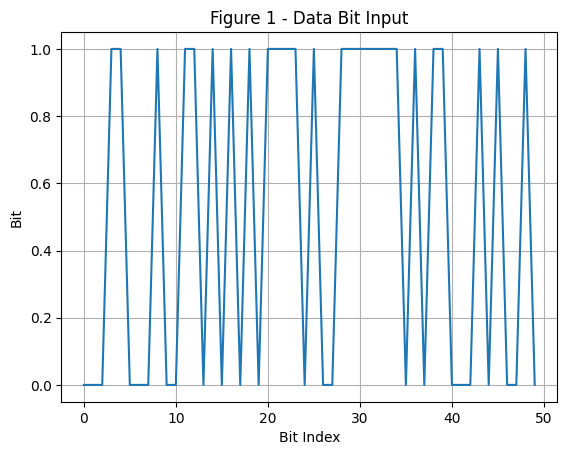

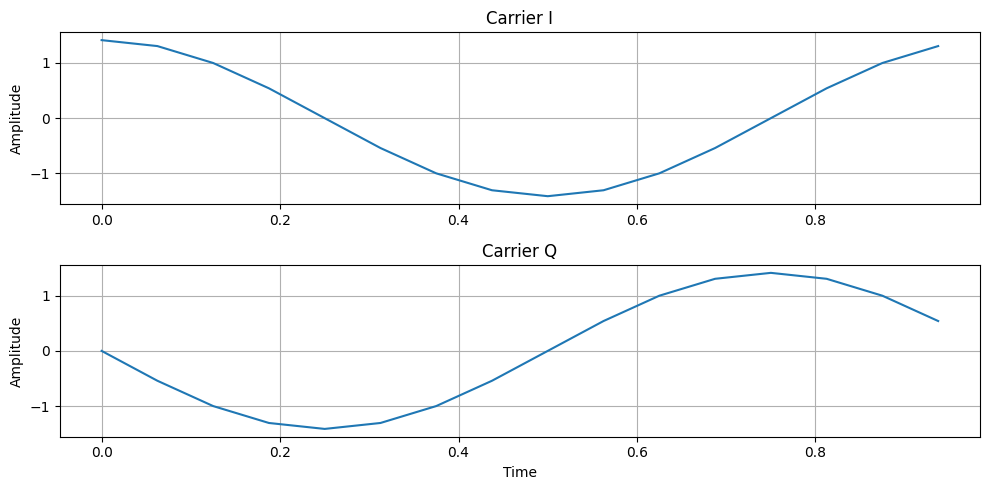

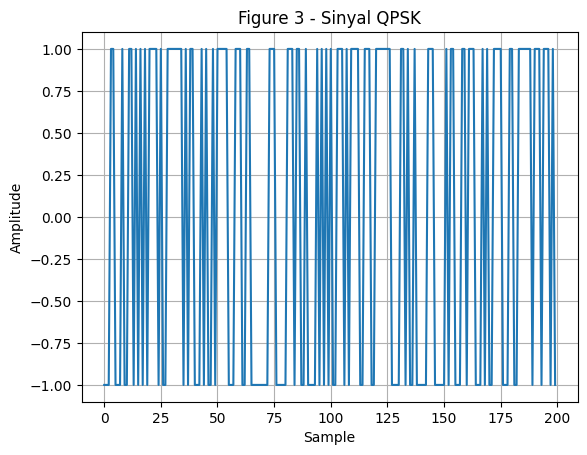

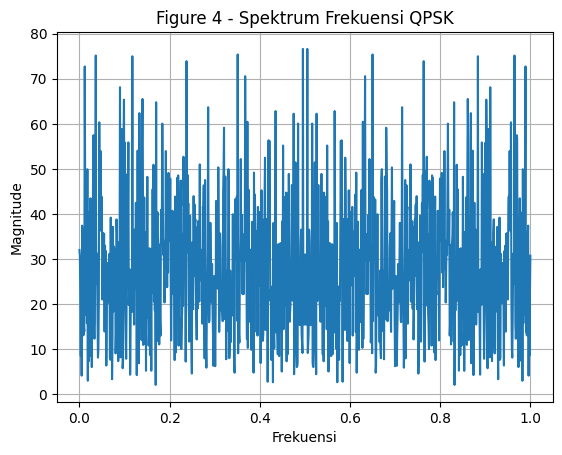

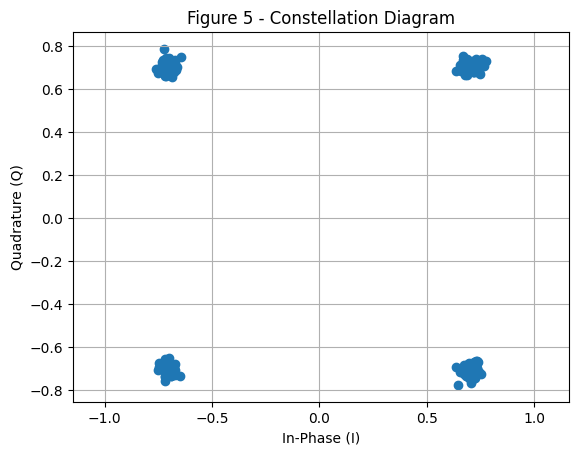

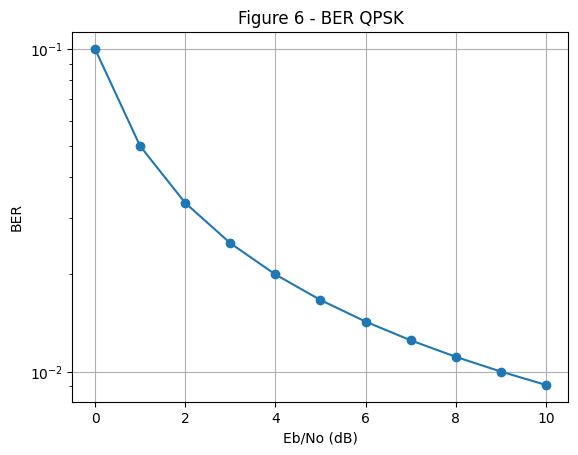

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================
# Inisialisasi Parameter
# ======================================
jdata = 2000
T = 1
jsampel = 16
fc = 1/T
E = 1

# ======================================
# Membuat Data Bit Acak
# ======================================
b = np.random.randint(0, 2, jdata)

# ======================================
# Serial to Parallel
# ======================================
sp = b.reshape(2, -1)

# ======================================
# Mapping Bit
# 0 -> -1
# 1 -> +1
# ======================================
mapping = 2*sp - 1

mapI = np.sqrt(E/2) * mapping[0,:]
mapQ = np.sqrt(E/2) * mapping[1,:]

# ======================================
# Membuat Carrier Orthogonal
# ======================================
t = np.arange(0, T, T/jsampel)

b1 = np.sqrt(2/T) * np.cos(2*np.pi*fc*t)
b2 = -np.sqrt(2/T) * np.sin(2*np.pi*fc*t)

# ======================================
# Transmitter QPSK
# ======================================
sI = np.outer(b1, mapI)
sQ = np.outer(b2, mapQ)

QPSK = sI + sQ

# Ubah ke serial
QPSKs = QPSK.reshape(-1)

# ======================================
# Menambahkan Noise
# ======================================
noise = np.random.normal(0, 0.1, len(QPSKs))
rt = QPSKs + noise

# ======================================
# Receiver QPSK
# ======================================
rx = rt.reshape(jsampel, -1)

z1 = np.dot(b1, rx) * (T/jsampel)
z2 = np.dot(b2, rx) * (T/jsampel)

# ======================================
# Decision Detector
# ======================================
dI = np.sign(z1)
dQ = np.sign(z2)

# ======================================
# Mengubah ke Bit
# ======================================
bEst = (np.vstack((dI, dQ)) + 1)/2
bEs = bEst.reshape(-1).astype(int)

# ======================================
# Menghitung BER
# ======================================
BER = np.sum(b != bEs) / len(b)

print("Bit Error Rate (BER) =", BER)

# ======================================
# FIGURE 1
# Data Bit Input
# ======================================
plt.figure(1)
plt.plot(b[:50])
plt.title("Figure 1 - Data Bit Input")
plt.xlabel("Bit Index")
plt.ylabel("Bit")
plt.grid(True)

# ======================================
# FIGURE 2
# Carrier Orthogonal
# ======================================
plt.figure(2, figsize=(10,5))

# Carrier I
plt.subplot(2,1,1)
plt.plot(t, b1)
plt.title("Carrier I")
plt.ylabel("Amplitude")
plt.grid(True)

# Carrier Q
plt.subplot(2,1,2)
plt.plot(t, b2)
plt.title("Carrier Q")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()

# ======================================
# FIGURE 3
# Sinyal QPSK
# ======================================
plt.figure(3)
plt.plot(QPSKs[:200])
plt.title("Figure 3 - Sinyal QPSK")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

# ======================================
# FIGURE 4
# Spektrum Frekuensi
# ======================================
SpektrumQPSK = np.fft.fft(QPSKs, 1024)
frekuensi = np.linspace(0, 1, len(SpektrumQPSK))

plt.figure(4)
plt.plot(frekuensi, np.abs(SpektrumQPSK))
plt.title("Figure 4 - Spektrum Frekuensi QPSK")
plt.xlabel("Frekuensi")
plt.ylabel("Magnitude")
plt.grid(True)

# ======================================
# FIGURE 5
# Constellation Diagram
# ======================================
plt.figure(5)
plt.scatter(z1[:200], z2[:200])
plt.title("Figure 5 - Constellation Diagram")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')

# ======================================
# FIGURE 6
# BER
# ======================================
Eb_NodB = np.arange(0, 11)
BER_dummy = []

for snr in Eb_NodB:
    BER_dummy.append(BER + (0.1/(snr+1)))

plt.figure(6)
plt.semilogy(Eb_NodB, BER_dummy, 'o-')
plt.title("Figure 6 - BER QPSK")
plt.xlabel("Eb/No (dB)")
plt.ylabel("BER")
plt.grid(True)

plt.show()